In [184]:
from jax import config
config.update("jax_enable_x64", True)
from pathlib import Path
import glob 

In [185]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 

from spectres import spectres

import jax.numpy as jnp 
from jax import vmap, jit 

import pickle 
import matplotlib.lines as mlines
import matplotlib.patches as mpatches


In [228]:
from sheap import Sheapectral
from sheap.Utils.Paper import plot_logdex_agreement,posterior_extraction,plot_ratio_histogram #agreement_stats,plot_logdex_agreement,median_with_errors,posterior_extraction,plot_logdex_agreement_v2,ResultAnalysis,plot_logdex_agreement_v3
from sheap.SheaProducts.Utils.MoldelSpectraReconstruction import MoldelSpectraReconstruction
from sheap.Assistants.parser_mapper import get_multiple_sample_params,get_sample_params,summarize_spectral_lines,get_sample_extraparams

In [187]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [188]:
#host 5100 / modelo 5100
#Pero es cont = bestfit- líneas de emisión - fe2 - Bal_cont - bal HO

In [189]:
with open("../pickle_spectra/bernal_spectras.pkl", "rb") as f:
	dict_spectra = pickle.load(f)
base_panda = pd.read_csv("../pickle_spectra/bernal_spectras.csv")

In [190]:
def Lha_from_smbh_fwhm(log_smbh, FWHM):
    """
    Compute Hα luminosity from SMBH mass and FWHM.

    Parameters
    ----------
    log_smbh : float or array
        log10(M_BH / Msun)
    FWHM : float or array
        Line FWHM in km/s

    Returns
    -------
    Lha : float or array
        Hα luminosity in erg/s
    """
    log_smbh = np.asarray(log_smbh)
    FWHM = np.asarray(FWHM)

    term = (
        log_smbh
        - np.log10(1.075)
        - 6.57
        - 2.06 * np.log10(FWHM / 1e3)
    ) / 0.47

    Lha = 1e42 * 10**term
    return np.where(log_smbh > 0, Lha, 0.0)

In [191]:
# !nvidia-smi

In [192]:
sheapspectral = Sheapectral.from_pickle("/data/favila/data_2/smbh_mass/sheap_notebook/notebooks/Bernal+25/SS25_montecarlo_sample_rachiv2.pkl")

In [194]:
sheapspectral.estimate_posteriors(only_sheaproducts=True)

Re-Getting posterior-params: 100%|██████████| 413/413 [02:55<00:00,  2.35it/s, it_s=0.3983] 


In [11]:
sheapspectral.result.posterior["montecarlo"].keys()

dict_keys(['posterior_result', 'num_samples', 'key_seed', 'summarize', 'time_elapsed'])

In [12]:
#sheapspectral.save_to_pickle("SS25_montecarlo_sample_rachiv2.pkl")

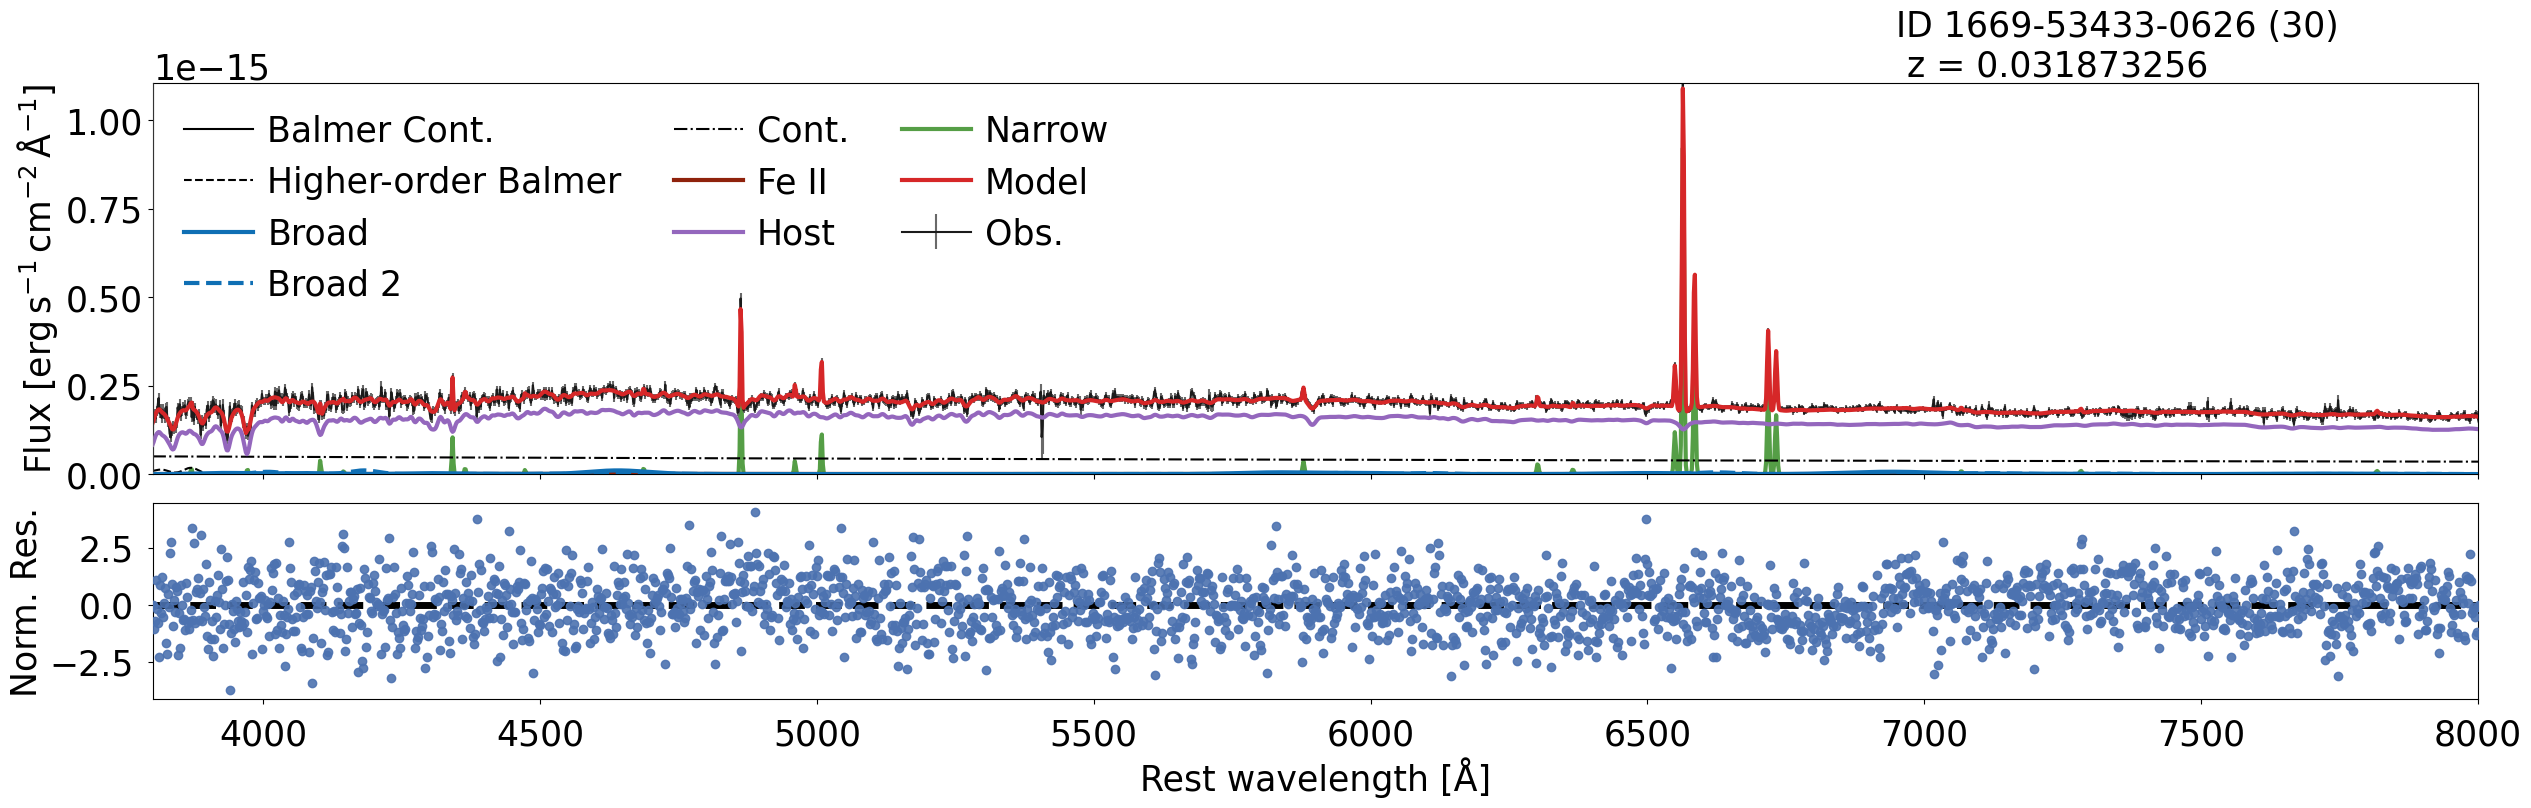

In [15]:
sheapspectral.modelplot.plot(30,add_legend=True,add_lines_name=False)

In [15]:
np.where(sheapspectral.result.chi2_red>9)

(array([  0,  35,  43,  48,  70, 181, 235, 265]),)

In [16]:
summarize_spectral_lines(sheapspectral.result.sheapmodel.lines)

=== SpectralLine summary ===
Counts by region:
  - balmer: 2
  - broad: 2
  - continuum: 1
  - fe: 1
  - host: 1
  - narrow: 1

Gaussian-ish entries (profile/subprofile contains 'gaussian'): 3
Gaussian-ish by region:
  - broad: 2
  - narrow: 1

Continuum components:
  - continuum / continuum1 (profile: powerlaw)

Line mappings (region / component):
  - broad / broad1: 18 lines
      Hε - 3970.072
      Hδ - 4101.742
      HeIc - 4143.761
      Hg - 4340.471
      HeId - 4471.479
      HeIId - 4685.710
      Hbeta - 4861.333
      HeIe - 5877.254
      Halpha - 6562.820
      HeIf - 7065.196
      HeIg - 7281.349
      HeIh - 7816.136
      NaIa - 5890.000
      NaI1a - 5896.000
      OIa - 6046.440
      OIb - 7002.230
      OIc - 7254.448
      OId - 7774.170
  - broad / broad2: 18 lines
      Hε - 3970.072
      Hδ - 4101.742
      HeIc - 4143.761
      Hg - 4340.471
      HeId - 4471.479
      HeIId - 4685.710
      Hbeta - 4861.333
      HeIe - 5877.254
      Halpha - 6562.820
    

{'region_counts': {'balmer': 2,
  'broad': 2,
  'continuum': 1,
  'fe': 1,
  'host': 1,
  'narrow': 1},
 'gaussian_total': 3,
 'gaussian_counts_by_region': {'broad': 2, 'narrow': 1},
 'family_maps': {('broad', 'broad', 1): ['Hε - 3970.072',
   'Hδ - 4101.742',
   'HeIc - 4143.761',
   'Hg - 4340.471',
   'HeId - 4471.479',
   'HeIId - 4685.710',
   'Hbeta - 4861.333',
   'HeIe - 5877.254',
   'Halpha - 6562.820',
   'HeIf - 7065.196',
   'HeIg - 7281.349',
   'HeIh - 7816.136',
   'NaIa - 5890.000',
   'NaI1a - 5896.000',
   'OIa - 6046.440',
   'OIb - 7002.230',
   'OIc - 7254.448',
   'OId - 7774.170'],
  ('broad', 'broad', 2): ['Hε - 3970.072',
   'Hδ - 4101.742',
   'HeIc - 4143.761',
   'Hg - 4340.471',
   'HeId - 4471.479',
   'HeIId - 4685.710',
   'Hbeta - 4861.333',
   'HeIe - 5877.254',
   'Halpha - 6562.820',
   'HeIf - 7065.196',
   'HeIg - 7281.349',
   'HeIh - 7816.136',
   'NaIa - 5890.000',
   'NaI1a - 5896.000',
   'OIa - 6046.440',
   'OIb - 7002.230',
   'OIc - 7254.

In [17]:
#sheapspectral.save_to_pickle("SS25_montecarlo_sample_rachi.pkl")

In [18]:
#sheapspectral.estimate_posteriors(only_sheaproducts=True)

In [16]:
ra = MoldelSpectraReconstruction(sheapspectral, jit_compile=True)
stars = ra.stars_Cont_5100()        
stars_best = ra.stars_Cont_5100_bestfit     # (N_obj,)  

In [17]:
stars

Array([[4.71402355e-07, 4.77179541e-07, 4.74739051e-07, ...,
        4.68113657e-07, 4.78660392e-07, 4.71032053e-07],
       [9.55490967e-01, 9.55636482e-01, 9.54761980e-01, ...,
        9.55999744e-01, 9.54495410e-01, 9.53513104e-01],
       [7.97418783e-01, 8.20524607e-01, 7.98306800e-01, ...,
        8.26239377e-01, 8.08045492e-01, 7.96887576e-01],
       ...,
       [2.08681854e-01, 2.02206276e-01, 2.38808269e-01, ...,
        2.30033733e-01, 2.49286029e-01, 1.40806050e-01],
       [2.92103954e-01, 3.12553762e-01, 3.27466422e-01, ...,
        2.80312572e-01, 2.89482265e-01, 3.06032129e-01],
       [3.44029274e-01, 3.17520022e-01, 3.35715667e-01, ...,
        3.23508137e-01, 3.60622483e-01, 3.43808980e-01]], dtype=float64)

In [134]:
p_lo, p_med, p_hi = np.percentile(stars, [100 * 0.16, 50, 100 * 0.84],axis=1)
median_stars_Cont_5100,low_stars_Cont_5100,up_stars_Cont_5100 = p_med, p_med - p_lo, p_hi - p_med
x =  base_panda.stars_Cont_5100.values #np.log10(bernal_FWHM)
y  = median_stars_Cont_5100
yerr_low = low_stars_Cont_5100
yerr_up = up_stars_Cont_5100

In [135]:
sum(base_panda.BHMassHa.values>0)

np.int64(384)

In [164]:
FWHM_halpha = base_panda.FWHMbr.values
BHMassHa = base_panda.BHMassHa.values #log_10
Lha=Lha_from_smbh_fwhm(BHMassHa,FWHM_halpha) 
main_mask = Lha ==0 # most probably type II agn 


In [165]:
xx = np.vstack([x]) 
#xx = np.where(main_mask, np.nan, xx)
yy = np.vstack([y ,yerr_up,yerr_low])
#yy = np.where(main_mask, np.nan, yy)

In [166]:
# data_dict = {"No BLR": {"x": np.vstack([x]) , "y":  np.vstack([y ,yerr_up,yerr_low]),"markeredgewidth":1.5},
# 			"With BLR": {"x": xx, "y":yy }}

In [177]:
data_dict = {"No BLR": {"x": np.where(~main_mask, np.nan, xx) , "y":  np.where(~main_mask, np.nan, yy),"markeredgewidth":1.5,"zorder":2,"snr": np.where(~main_mask, np.nan, sheapspectral.snr)},
			"With BLR": {"x": np.where(main_mask, np.nan, xx), "y":np.where(main_mask, np.nan, yy) ,"snr": np.where(main_mask, np.nan, sheapspectral.snr)}}

In [178]:
median_stars_Cont_5100[264],low_stars_Cont_5100[264],up_stars_Cont_5100[264]

(np.float64(0.07109540977888718),
 np.float64(0.020286287330723032),
 np.float64(0.02047469413871912))

In [179]:
sheapspectral.snr[310]

np.float64(19.26831168328425)

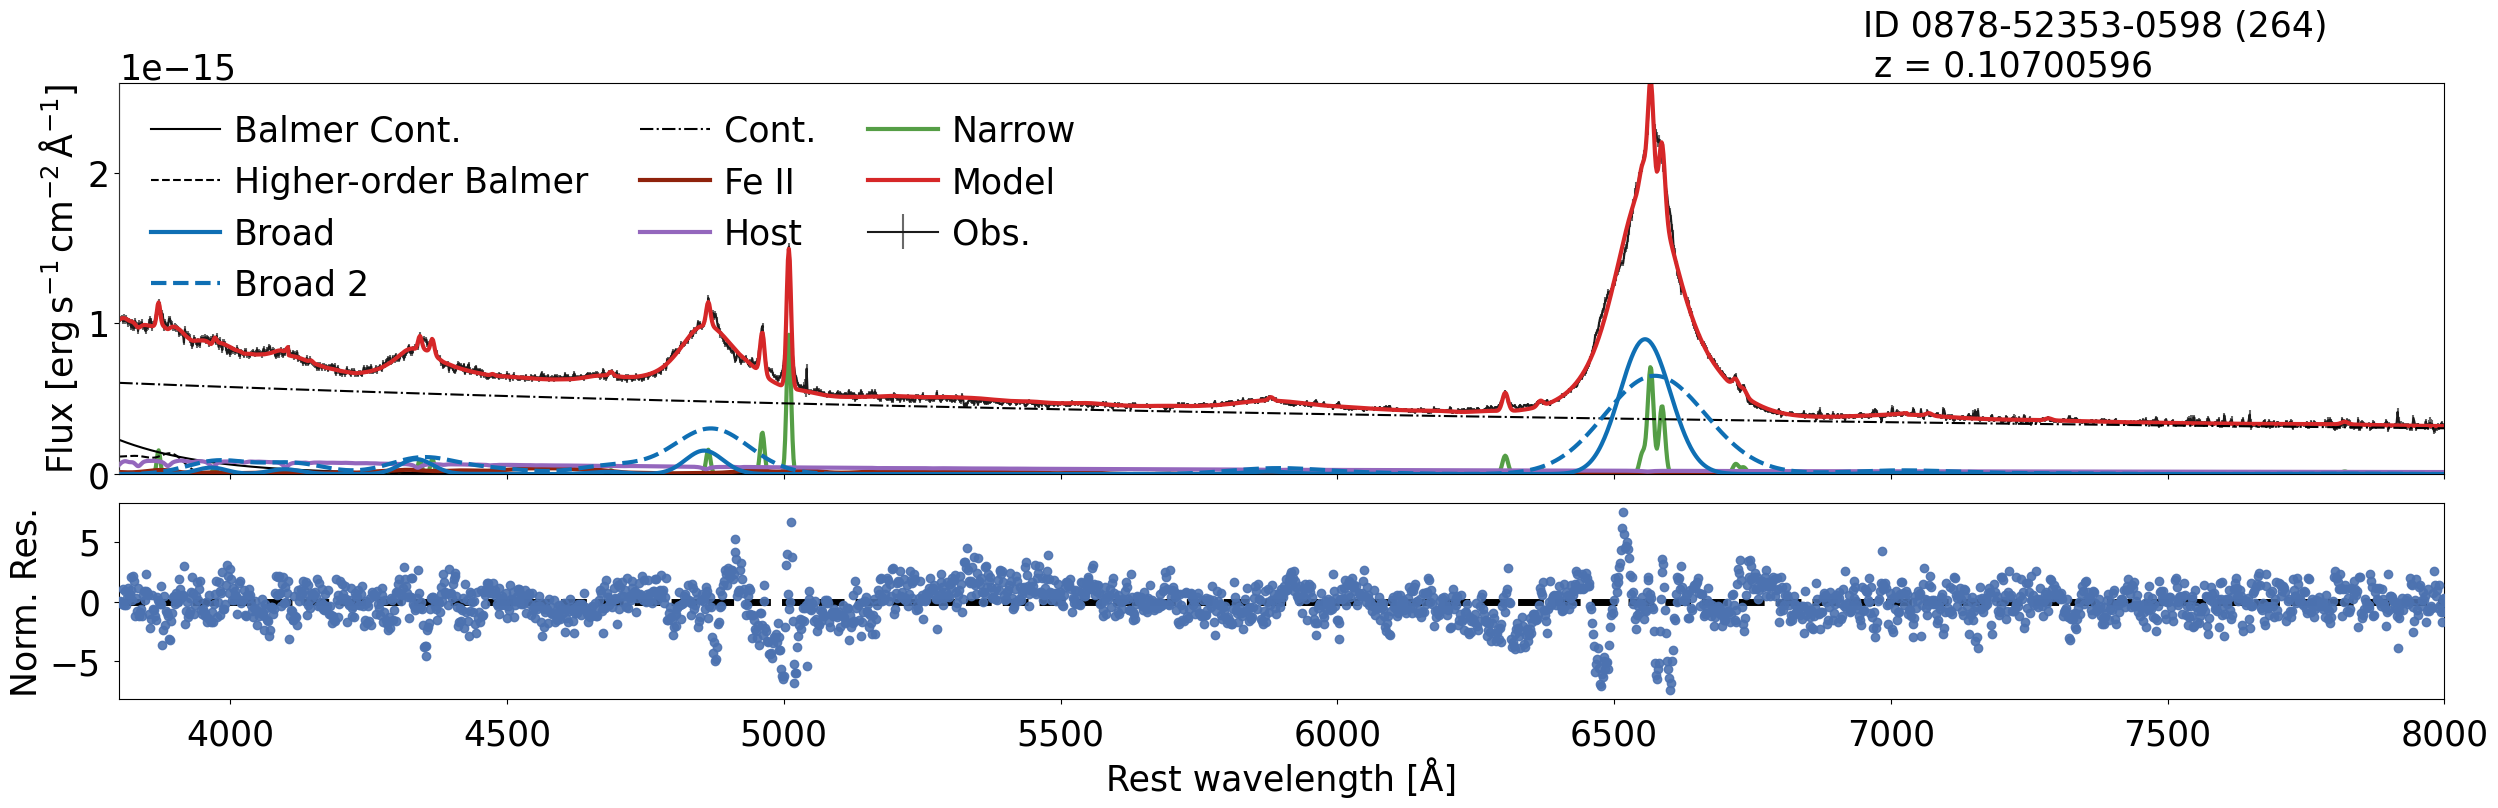

In [180]:
sheapspectral.modelplot.plot(264)

In [181]:
# data_dict = {"all": {"x":  xx, "y":yy}}

Bad errors plus in index [  0   2   3   4   5   6   8   9  10  12  13  14  15  16  17  18  19  20
  21  22  26  27  28  29  30  32  33  34  35  37  38  39  40  41  42  44
  46  47  49  50  51  52  54  55  57  58  59  60  62  64  65  66  67  68
  69  70  71  72  73  74  75  76  77  78  79  80  81  82  84  86  87  88
  89  90  92  93  94  95  97  98  99 100 101 102 104 105 107 108 109 110
 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129
 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147
 148 149 150 151 152 153 154 156 157 158 159 160 161 162 163 164 165 166
 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 184 185
 187 188 189 190 191 193 194 195 196 197 198 199 200 201 202 203 204 205
 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 222 223 224
 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243
 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261
 262 263 264 265 266 267 2

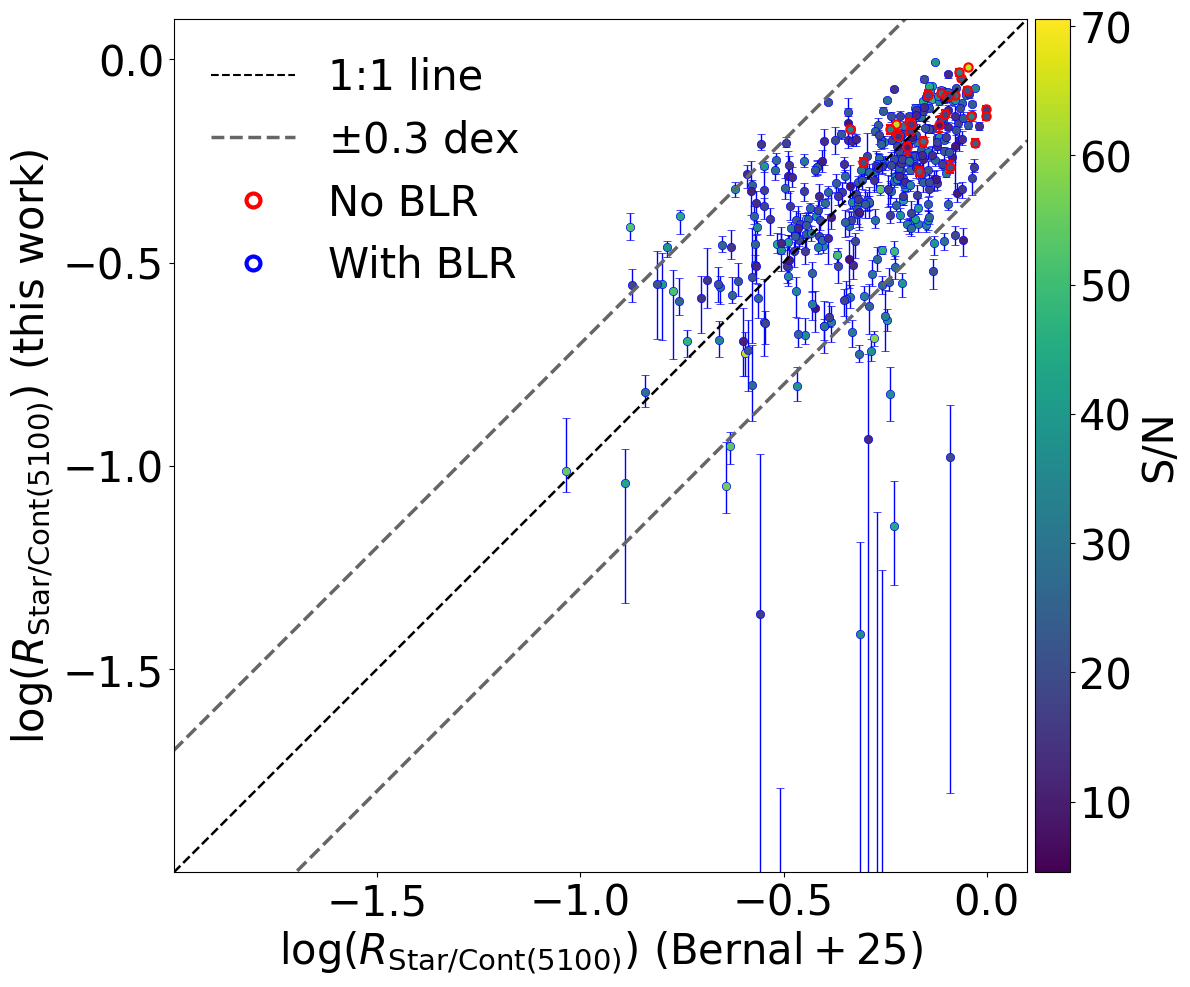

In [183]:
text = None#{"text":r"R$_{\mathrm{Stars/Cont}}$"+"\n"+r"at 5100 $\AA$","xpos":0.5,"ypos":0.2}
save_file = None #"images/scont5100_bernal.pdf"
sn = sheapspectral.snr
_ = plot_logdex_agreement(data_dict,lims=[-2,0.1],ref_label="(5100)",ref_work="Bernal+25",label_mode="starcont_clasic",add_numbers=False,legend_loc="upper left",sn=sn,label_colorbar="S/N"
                             ,text=text,markers=("o","o"),colors=("r","b"),save_file=save_file)

In [ ]:
sheapspectral.result.posterior["montecarlo"].keys()

In [26]:
posterior_pandas = posterior_extraction(sheapspectral,extra_key="extra_params_combined_kinematic")#extra_key="")#extra_combined_pyqso

mask = (
	(posterior_pandas["line"] == "Halpha") &
	(posterior_pandas["SMBHEstimator"] == "MR16_global_Halpha_L5100_FWHM") &
	(posterior_pandas["quantity"] == "vwidth_kms")
)

# All Ledd medians:
Halpha_FWHM_median = posterior_pandas.loc[mask, "median"].to_numpy().flatten().astype(float)
Halpha_FWHM_err_plus = posterior_pandas.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
Halpha_FWHM_err_minus = posterior_pandas.loc[mask, "err_minus"].to_numpy().flatten().astype(float)


mask = (
	(posterior_pandas["line"] == "Halpha") &
	(posterior_pandas["SMBHEstimator"] == "RV15_Halpha_Lha") &
	(posterior_pandas["quantity"] == "Lline")
)

# All Ledd medians:
Halpha_Lline_median = posterior_pandas.loc[mask, "median"].to_numpy().flatten().astype(float)
Halpha_Lline_err_plus = posterior_pandas.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
Halpha_Lline_err_minus = posterior_pandas.loc[mask, "err_minus"].to_numpy().flatten().astype(float)


mask = (
	(posterior_pandas["line"] == "Halpha") &
	(posterior_pandas["SMBHEstimator"] == "MR16_global_Halpha_L5100_FWHM") &
	(posterior_pandas["quantity"] == "Lwave")
)

# All Ledd medians:
Halpha_Lwave_median = posterior_pandas.loc[mask, "median"].to_numpy().flatten().astype(float)
Halpha_Lwave_err_plus = posterior_pandas.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
Halpha_Lwave_err_minus = posterior_pandas.loc[mask, "err_minus"].to_numpy().flatten().astype(float)

/share/cav/data/favila/smbh_mass/sheap/sheap/Utils/Paper.py:147: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [27]:
# sheapspectral.result.posterior["montecarlo"]["posterior_result"].keys()

In [23]:
posterior = sheapspectral.result.posterior["montecarlo"]["posterior_result"]
#ssamples_flux_MgII = get_sample_params(posterior,"Hbeta","combined_params","Hbeta","eqw").squeeze()

In [ ]:
# get_sample_params(sheapspectral.result.posterior["montecarlo"]["posterior_result"],"basic_params_combined_kinematic","broad","Halpha","eqw")

: 

In [204]:
# sheapspectral.result.posterior["montecarlo"]["posterior_result"]['2015-53819-0251']["basic_params_combined_kinematic"]["eqw"][:,0]

In [67]:
# eqw_vc = np.array([sheapspectral.result.posterior["montecarlo"]["posterior_result"][i]["combined_params"]['Halpha']["eqw"] for i in sheapspectral.result.posterior["montecarlo"]["posterior_result"].keys()]).squeeze()

In [267]:
# eqw_vc = get_sample_params(sheapspectral.result.posterior["montecarlo"]["posterior_result"],"basic_params_combined_kinematic","broad","Halpha","eqw").squeeze()

# #eqw_vc =np.array([sheapspectral.result.posterior["montecarlo"]["posterior_result"][i]["basic_params_combined_kinematic"]["broad"]["eqw"][:,0] for i in sheapspectral.result.posterior["montecarlo"]["posterior_result"].keys()]).squeeze()

In [264]:
p_lo, p_med, p_hi = np.percentile(eqw_vc, [100 * 0.16, 50, 100 * 0.84],axis=1)
median_eqw_vc,low_eqw_vc,up_eqw_vc = p_med, p_med - p_lo, p_hi - p_med
#median_eqw_vc[median_eqw_vc>1000] = 0

In [265]:
np.where(median_eqw_vc>600)

(array([186, 217, 313]),)

In [266]:
median_eqw_vc[34],low_eqw_vc[34],up_eqw_vc[34]

(np.float64(23.169702781475763),
 np.float64(0.5666037752440971),
 np.float64(1.7961563683148398))

In [77]:
# median_eqw_vc[34],low_eqw_vc[34],up_eqw_vc[34]

In [97]:
# bernal_EWHabr[313],median_eqw_vc[313]

In [79]:
#186 is bad 
#24

In [80]:
# median_eqw_vc[217]

NaN / non-finite entries at indices: []
Number of NaNs / non-finite values: 0


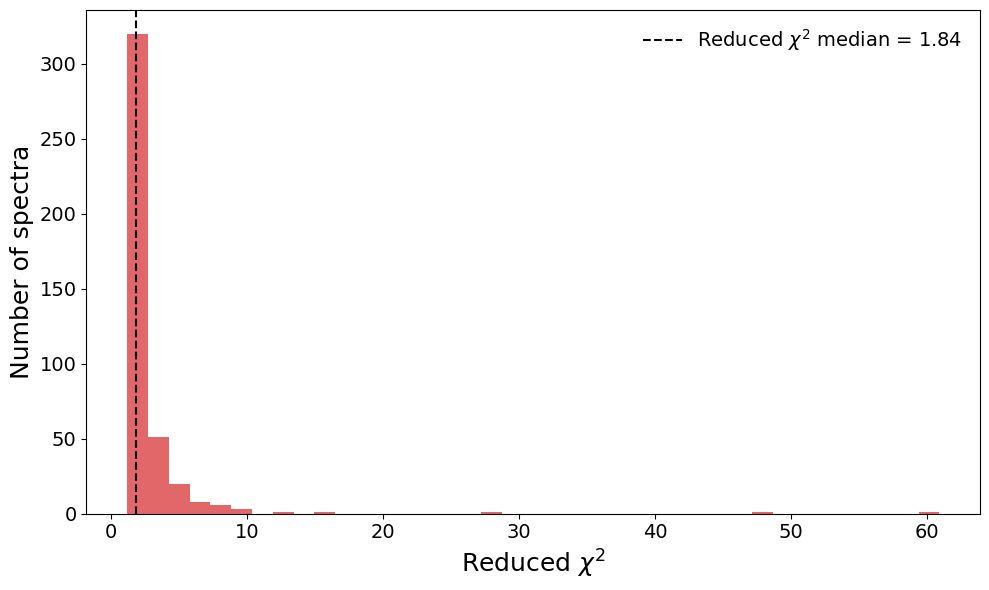

In [124]:
sheapspectral.plot_chi2

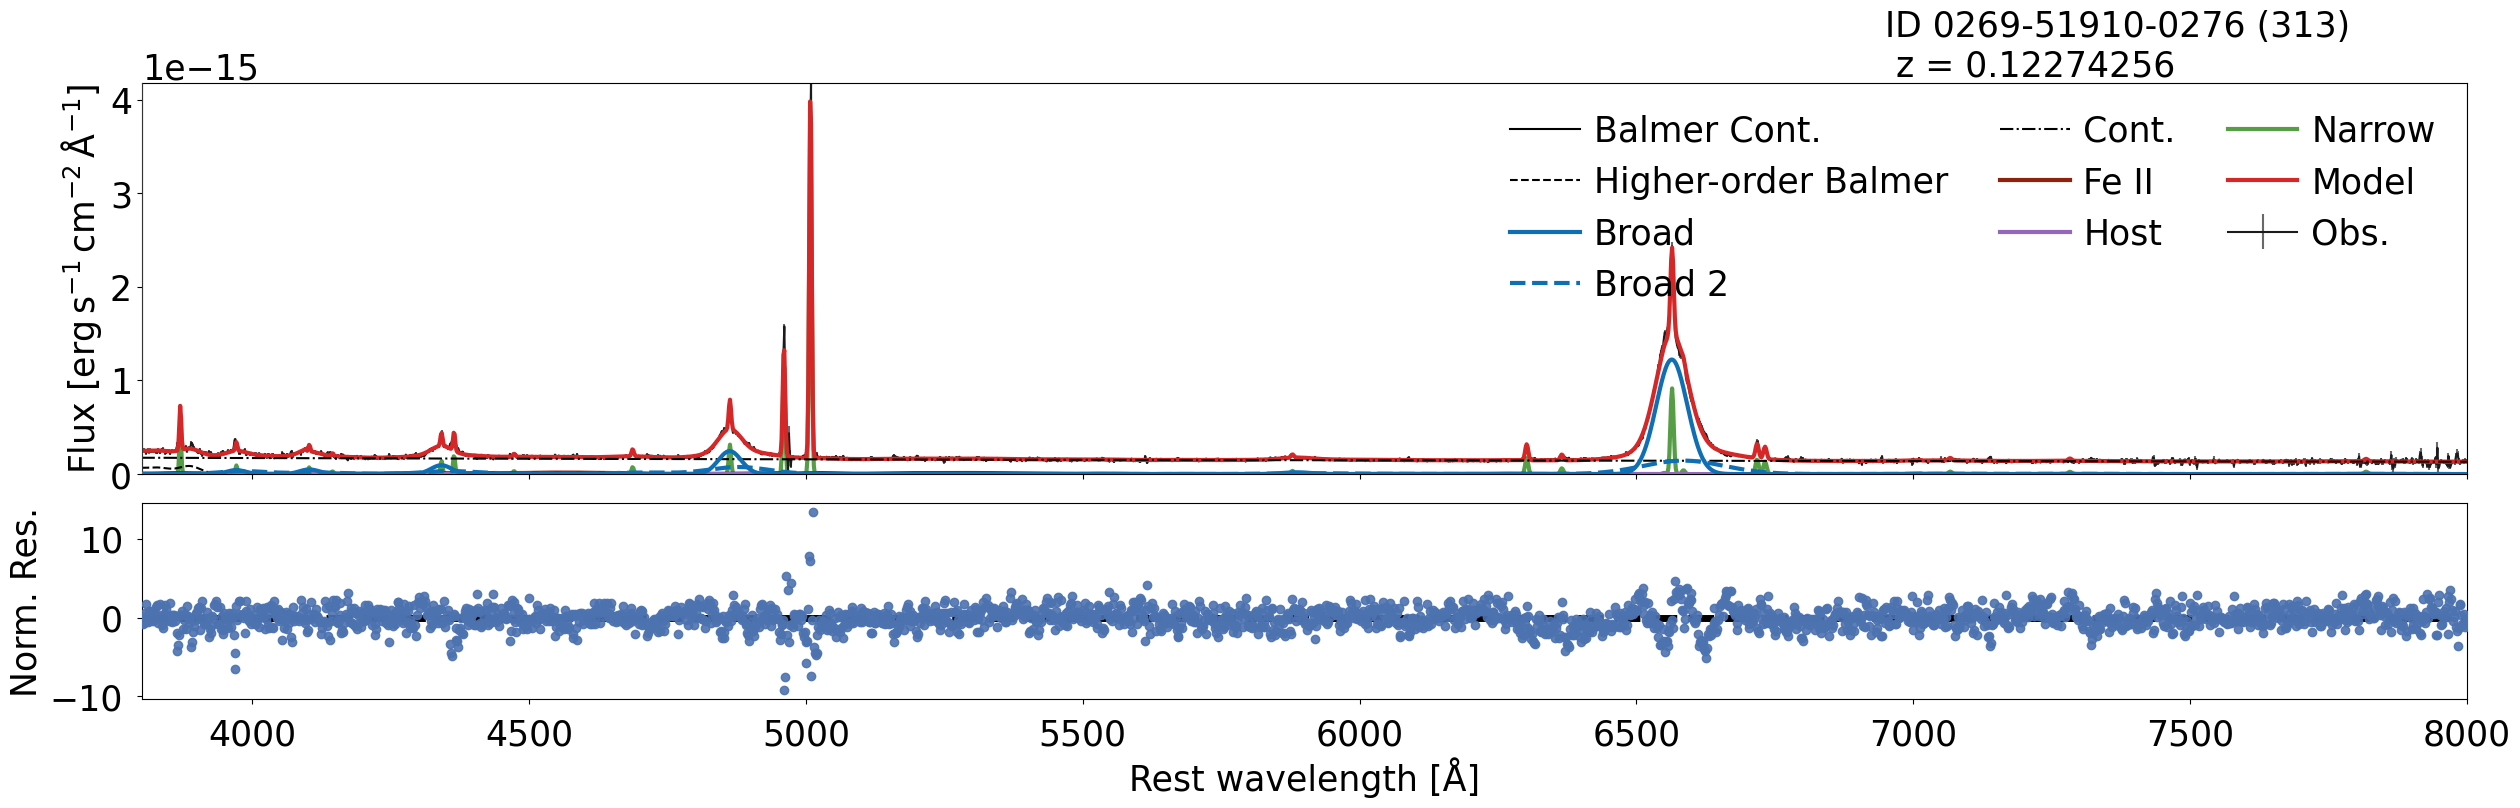

In [108]:
sheapspectral.modelplot.plot(313)

In [100]:
# np.where(bernal_EWHabr>800)

In [83]:
# plt.hist(bernal_EWHabr)

https://cdsarc.cds.unistra.fr/ftp/J/A+A/694/A127/ReadMe

In [101]:
# 96-104  F9.3  km/s       FWHMbr        BEL component FWHM (FWHM_br) (2)
#  106-114  F9.3  km/s      bFWHMbr        FWHMbr percentil 16 (FWHM_br_p16)
#  116-124  F9.3  km/s      BFWHMbr        FWHMbr percentil 84 (FWHM_br_p84)

bernal_Lum5100 = base_panda.Lum5100.values
bernal_LHatotal = base_panda.LHatotal.values
bernal_SMBH_LHa = base_panda.BHMassHa.values
bernal_SMBH_Lcont = base_panda.BHMass.values


bernal_FWHM = base_panda.FWHMbr.values
bernal_FWHM_err_plus = np.abs(base_panda.BFWHMbr.values - base_panda.FWHMbr.values)+1e-5
bernal_FWHM_err_minus =  np.abs(base_panda.FWHMbr.values - base_panda.bFWHMbr) +1e-5


bernal_Lum5100 = base_panda.Lum5100.values
bernal_Lum5100_err_plus = np.abs(base_panda.BLum5100.values - base_panda.Lum5100.values)+1e-5
bernal_Lum5100_err_minus =  np.abs(base_panda.Lum5100.values - base_panda.bLum5100.values) +1e-5

bernal_LHatotal = base_panda.LHatotal.values


bernal_EWHabr = base_panda.EWHabr.values
bernal_EWHabr_err_plus = np.abs(base_panda.BEWHabr.values - base_panda.EWHabr.values)+1e-5
bernal_EWHabr_err_minus =  np.abs(base_panda.EWHabr.values - base_panda.bEWHabr.values) +1e-5

#bernal_LHatotal_err_plus = np.abs(base_panda.BLHatotal.values - base_panda.LHatotal.values)+1e-5
#bernal_LHatotal_err_minus =  np.abs(base_panda.LHatotal.values - base_panda.bLHatotal.values) +1e-5


In [102]:
# plt.hist(base_panda.EWHabr.values)
# plt.hist(base_panda.BEWHabr.values)
# plt.hist(base_panda.bEWHabr.values)

In [103]:
# bernal_EWHabr

In [104]:
# EWHabr

Bad errors plus in index [  1   7  11  23  24  25  31  36  43  45  48  53  56  61  63  83  85  91
  96 103 106 111 155 183 186 192 221 225 272], replacing per 100% error
Bad errors minus in index [  1   7  11  23  24  25  31  36  43  45  48  53  56  61  63  83  85  91
  96 103 106 111 155 183 186 192 221 225 272] 100% error
Bad errors plus in index [  1   7  11  23  24  25  31  36  43  45  48  53  56  61  63  83  85  91
  96 103 106 111 155 183 186 192 221 225 272], replacing per 100% error
Bad errors minus in index [  1   7  11  23  24  25  31  36  43  45  48  53  56  61  63  83  85  91
  96 103 106 111 155 183 186 192 221 225 272] 100% error


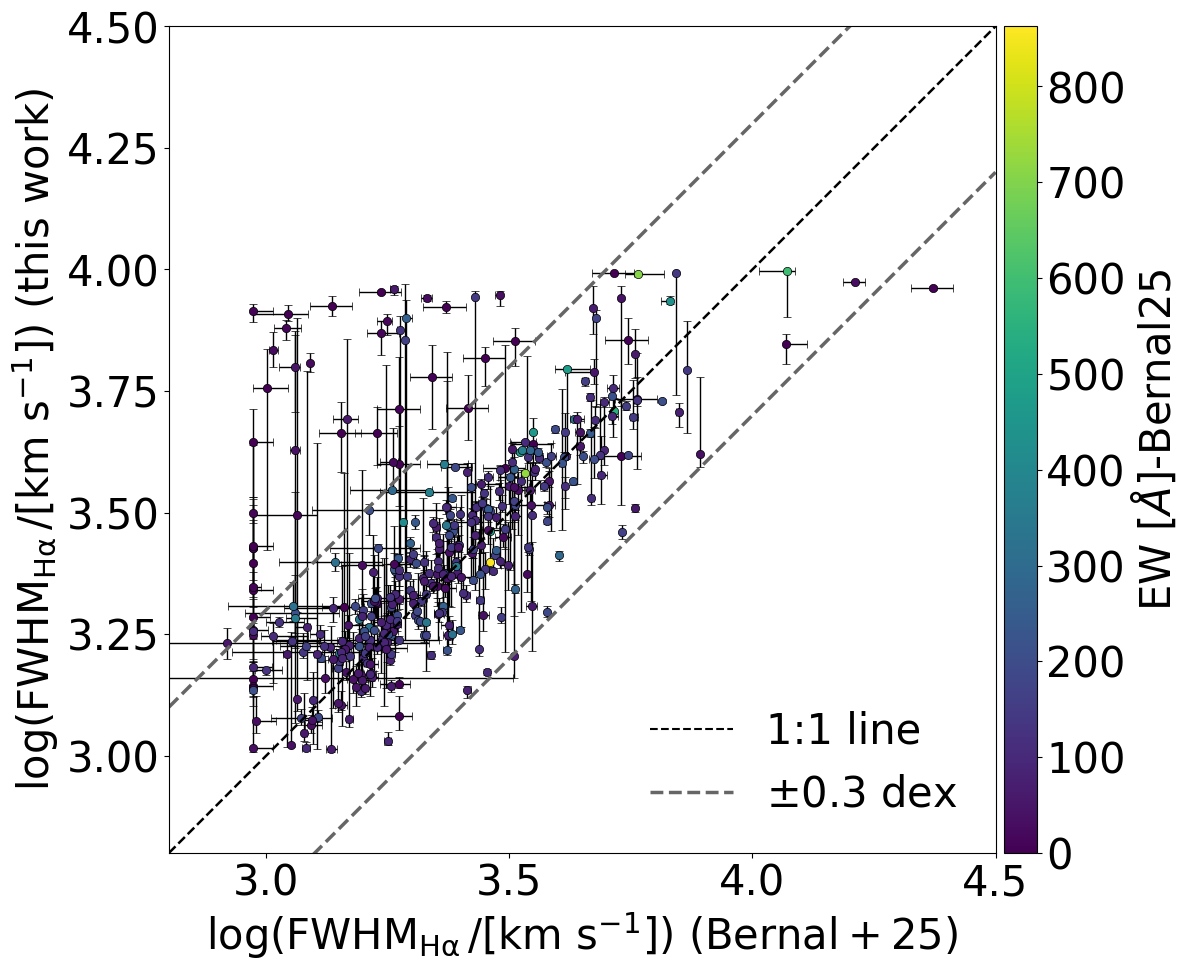

In [112]:
x = np.vstack([bernal_FWHM,bernal_FWHM_err_plus,bernal_FWHM_err_minus]) 
y = np.vstack([Halpha_FWHM_median,Halpha_FWHM_err_plus,Halpha_FWHM_err_minus])

xx = np.vstack([bernal_FWHM,bernal_FWHM_err_plus,bernal_FWHM_err_minus]) 
xx = np.where(main_mask, np.nan, xx)
yy = np.vstack([Halpha_FWHM_median,Halpha_FWHM_err_plus,Halpha_FWHM_err_minus])
yy = np.where(main_mask, np.nan, yy)


data_dict = {r"Values Bernal+25": {
		"x": xx,          # (2, N) symmetric error
		"y": yy,  # (3, N) +/-
	},}
text = None#{"text":r"Combined FWHM H$\alpha$","xpos":0.26,"ypos":0.9}
save_file = None #"images/fwhm_compare_bernal.pdf"
_=plot_logdex_agreement(data_dict,lims=[2.8,4.5],
                        ref_label=r"H\alpha",label_mode="fwhm_clasic",ref_work="Bernal+25"
                        ,add_numbers=False,remove_scater_legend=True
                        ,sn=bernal_EWHabr,label_colorbar=r"EW $[\AA]$-Bernal25"#-this work"
                        ,text=text,save_file=save_file)

In [115]:
_

(<Figure size 1200x1200 with 2 Axes>,
 <Axes: xlabel='$\\log(\\mathrm{FWHM}_{\\mathrm{H\\alpha}}\\, /[\\mathrm{km\\ s^{-1}}])\\ \\mathrm{(Bernal+25)}$', ylabel='$\\log(\\mathrm{FWHM}_{\\mathrm{H\\alpha}}\\, /[\\mathrm{km\\ s^{-1}}])\\ \\mathrm{(this\\ work)}$'>,
 {'Values Bernal+25': {'n_in': 341,
   'n_tot': 384,
   'pct': 88.80208333333333,
   'band': 0.3,
   'idx_out': [8,
    14,
    16,
    17,
    27,
    32,
    33,
    34,
    38,
    39,
    51,
    52,
    59,
    64,
    70,
    71,
    72,
    80,
    82,
    93,
    95,
    100,
    110,
    125,
    128,
    139,
    145,
    159,
    163,
    165,
    193,
    201,
    206,
    216,
    224,
    226,
    232,
    233,
    237,
    269,
    273,
    285,
    303]}},
 None)

In [116]:
H0=70 #km/s/Mpc
c = 299792.458
r=(sheapspectral.z*c)/H0 #Mpc
# 3.08568e24
r= r*3.086e24 #cm

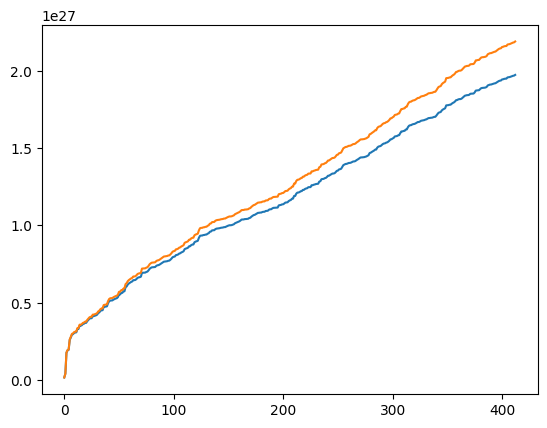

In [117]:
plt.plot(r)
plt.plot(sheapspectral._calcualte_d())

In [118]:
# flux=h[1].data['Best-fit'][idx]*wv*scf*uscf

(array([ 5., 21., 31., 44., 48., 61., 45., 50., 45., 63.]),
 array([1.00144102, 1.02443218, 1.04742334, 1.07041449, 1.09340565,
        1.11639681, 1.13938796, 1.16237912, 1.18537027, 1.20836143,
        1.23135259]),
 <BarContainer object of 10 artists>)

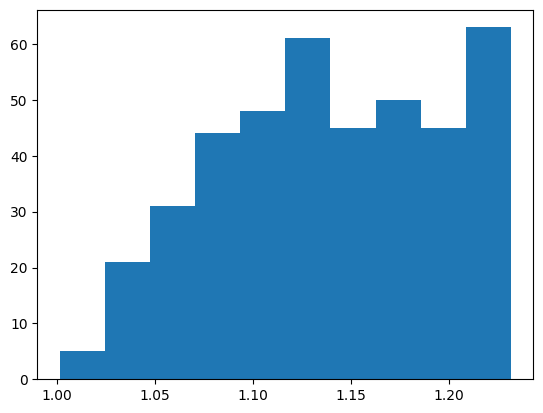

In [119]:
plt.hist((sheapspectral._calcualte_d()**2/r**2))

Bad errors plus in index [  1   7  11  23  24  25  31  36  43  45  48  53  56  61  63  83  85  91
  96 103 106 111 155 183 186 192 221 225 243 272], replacing per 100% error
Bad errors minus in index [  1   4   7  11  23  24  25  31  36  43  45  48  53  56  61  63  65  80
  83  85  91  96 103 106 111 155 183 186 192 221 225 239 243 249 272] 100% error
Bad errors plus in index [  1   7  11  23  24  25  31  36  43  45  48  53  56  61  63  83  85  91
  96 103 106 111 155 183 186 192 221 225 272], replacing per 100% error
Bad errors minus in index [  1   7  11  23  24  25  31  36  43  45  48  53  56  61  63  83  85  91
  96 103 106 111 155 183 186 192 221 225 272] 100% error


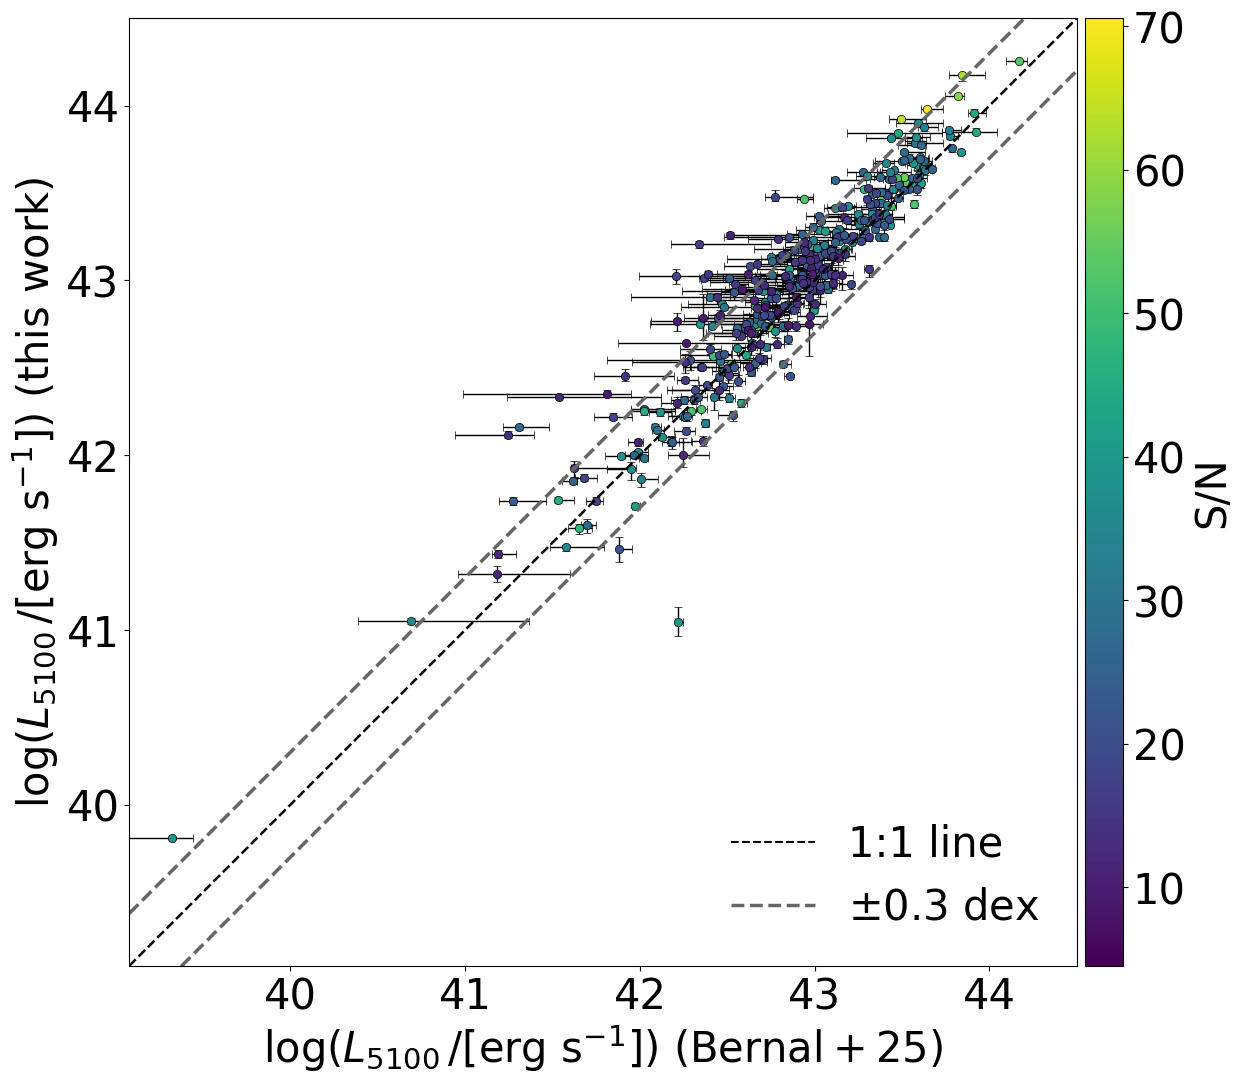

In [120]:
x = np.vstack([bernal_Lum5100,bernal_Lum5100_err_plus,bernal_Lum5100_err_minus])
y = np.vstack([Halpha_Lwave_median,Halpha_Lwave_err_plus,Halpha_Lwave_err_minus])

xx = np.vstack([bernal_Lum5100,bernal_Lum5100_err_plus,bernal_Lum5100_err_minus]) * (sheapspectral._calcualte_d()/r)**2 *(1+sheapspectral.z)
xx = np.where(main_mask, np.nan, xx)
yy = np.vstack([Halpha_Lwave_median,Halpha_Lwave_err_plus,Halpha_Lwave_err_minus])
yy = np.where(main_mask, np.nan, yy)


data_dict = {
	r"Values Bernal+25": {
		"x": xx,          # (2, N) symmetric error
		"y": yy,  # (3, N) +/-
	},}
text = None#{"text":r"$\lambda L_{\lambda}(5100\,\AA)$","xpos":0.2,"ypos":0.8}
_=plot_logdex_agreement(data_dict,label_mode="l_clasic"
                        ,ref_label="5100",ref_work="Bernal+25",remove_scater_legend=True
                        ,lims= None,add_numbers=False
                        ,sn=sheapspectral.snr,label_colorbar="S/N",text=text
                        ,save_file="images/l5100_compare_bernal.pdf")#

In [123]:
_

(<Figure size 1200x1200 with 2 Axes>,
 <Axes: xlabel='$\\log(L_{\\mathrm{H}\\alpha}\\, /[\\mathrm{erg\\ s^{-1}}])\\ \\mathrm{(Bernal+25)}$', ylabel='$\\log(L_{\\mathrm{H}\\alpha}\\, /[\\mathrm{erg\\ s^{-1}}])\\ \\mathrm{(this\\ work)}$'>,
 {'Values Bernal+25': {'n_in': 336,
   'n_tot': 384,
   'pct': 87.5,
   'band': 0.3,
   'idx_out': [4,
    8,
    13,
    15,
    17,
    21,
    26,
    27,
    29,
    33,
    38,
    59,
    64,
    65,
    70,
    71,
    72,
    79,
    80,
    82,
    90,
    93,
    95,
    100,
    114,
    128,
    142,
    159,
    163,
    165,
    166,
    175,
    179,
    181,
    184,
    201,
    216,
    224,
    232,
    237,
    244,
    247,
    266,
    269,
    285,
    294,
    303,
    334]}},
 None)

Bad errors plus in index [  1   7  11  23  24  25  31  36  43  45  48  53  56  61  63  83  85  91
  96 103 106 111 155 183 186 192 221 225 272], replacing per 100% error
Bad errors minus in index [  1   7  11  23  24  25  31  36  43  45  48  53  56  61  63  83  85  91
  96 103 106 111 155 183 186 192 221 225 272] 100% error


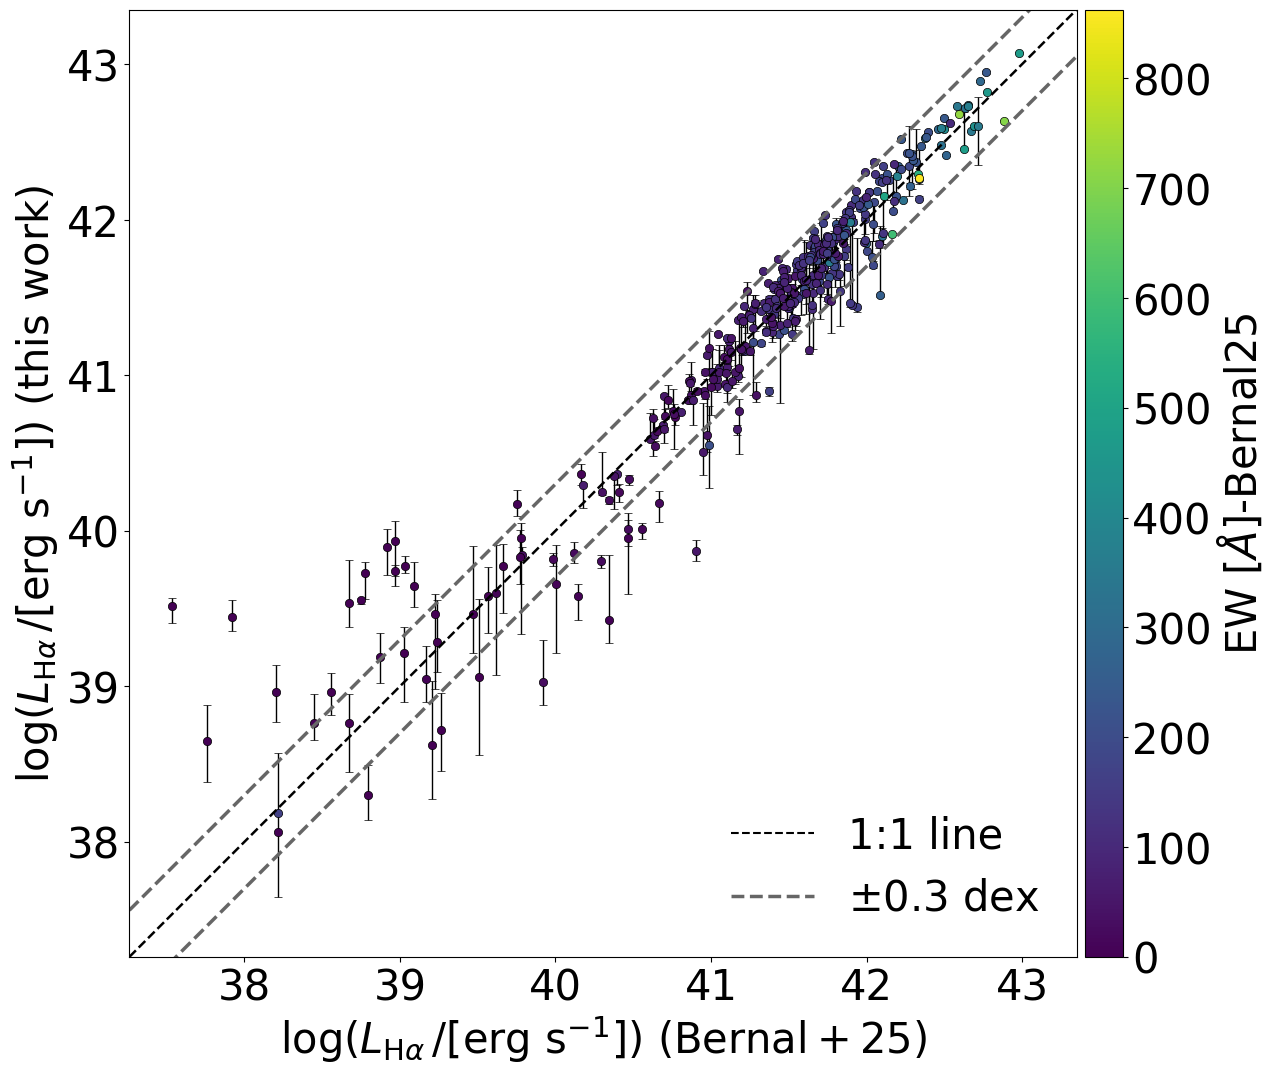

In [122]:
x = np.vstack([Lha])
y = np.vstack([Halpha_Lline_median,Halpha_Lline_err_plus,Halpha_Lline_err_minus])

l_xx = np.vstack([Lha]) * (sheapspectral._calcualte_d()/r)**2 *(1+sheapspectral.z)
l_xx = np.where(main_mask, np.nan, l_xx)
l_yy = np.vstack([Halpha_Lline_median,Halpha_Lline_err_plus,Halpha_Lline_err_minus])
l_yy = np.where(main_mask, np.nan, l_yy)

data_dict = {
	r"Values Bernal+25": {
		"x": l_xx,          # (2, N) symmetric error
		"y": l_yy,  # (3, N) +/-
	},}
sn = bernal_EWHabr #sheapspectral.snr
save_file = None#"images/lhalpa_compare.pdf"
label_colorbar = r"EW $[\AA]$-Bernal25" #"S/N"
_=plot_logdex_agreement(data_dict,label_mode="ll_clasic"
                        ,ref_label=r"\mathrm{H}\alpha",ref_work="Bernal+25",remove_scater_legend=True
                        ,lims= None
                        ,add_numbers=False
                        ,sn=sn,label_colorbar=label_colorbar,save_file=save_file)#

In [113]:
_

(<Figure size 1200x1200 with 2 Axes>,
 <Axes: xlabel='$\\log(\\mathrm{FWHM}_{\\mathrm{H\\alpha}}\\, /[\\mathrm{km\\ s^{-1}}])\\ \\mathrm{(Bernal+25)}$', ylabel='$\\log(\\mathrm{FWHM}_{\\mathrm{H\\alpha}}\\, /[\\mathrm{km\\ s^{-1}}])\\ \\mathrm{(this\\ work)}$'>,
 {'Values Bernal+25': {'n_in': 341,
   'n_tot': 384,
   'pct': 88.80208333333333,
   'band': 0.3,
   'idx_out': [8,
    14,
    16,
    17,
    27,
    32,
    33,
    34,
    38,
    39,
    51,
    52,
    59,
    64,
    70,
    71,
    72,
    80,
    82,
    93,
    95,
    100,
    110,
    125,
    128,
    139,
    145,
    159,
    163,
    165,
    193,
    201,
    206,
    216,
    224,
    226,
    232,
    233,
    237,
    269,
    273,
    285,
    303]}},
 None)

(array([ 22., 260.,  89.,   5.,   4.,   2.,   0.,   0.,   0.,   2.]),
 array([0.01064584, 0.46277631, 0.91490678, 1.36703725, 1.81916772,
        2.27129819, 2.72342866, 3.17555913, 3.62768961, 4.07982008,
        4.53195055]),
 <BarContainer object of 10 artists>)

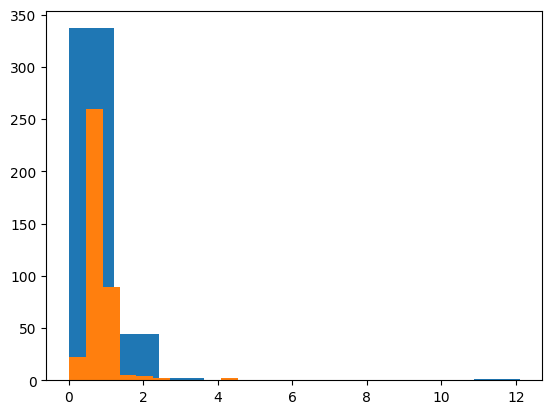

In [117]:
plt.hist(xx[0]/yy[0])
plt.hist(l_xx[0]/l_yy[0])
#plt.hist((r**2/sheapspectral._calcualte_d()**2))

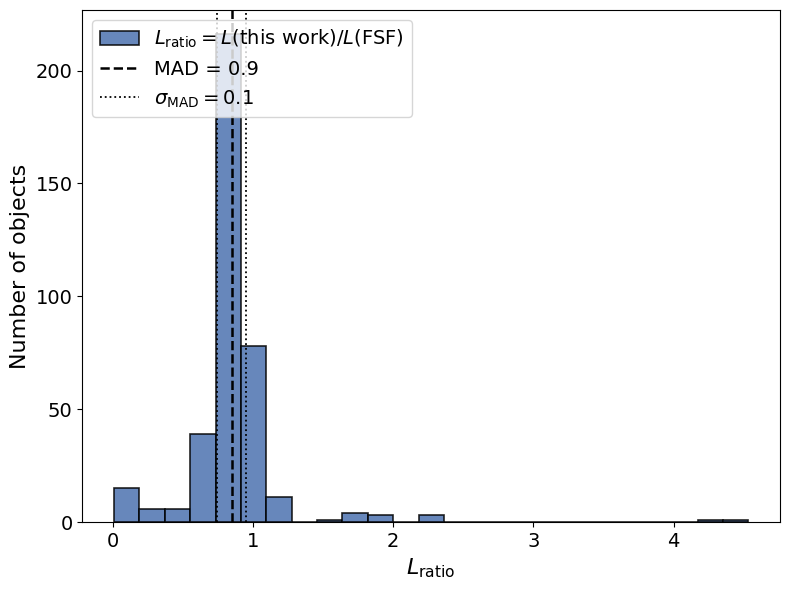

In [121]:
ratio = l_xx[0] / l_yy[0]
ratio = ratio[np.isfinite(ratio)]
fig, ax = plot_ratio_histogram(
	ratio,
	bins=25,
	figsize=(8, 6),
	color="#4C72B0",
	edgecolor="black",
	alpha=0.85,
	label=r"$L_{\mathrm{ratio}} = L(\mathrm{this\ work}) / L(\mathrm{FSF})$",
	xlabel=r"$L_{\mathrm{ratio}}$",
	add_median_value=True,
	legend_loc='upper left',
	#ylim=[0,90],
	#xlim=[-0.1,2.4]
)


/data/favila/data_2/vscode-temp/ipykernel_3383625/3581547706.py:1: RuntimeWarning: divide by zero encountered in divide
  ratio = yy[0] / xx[0]


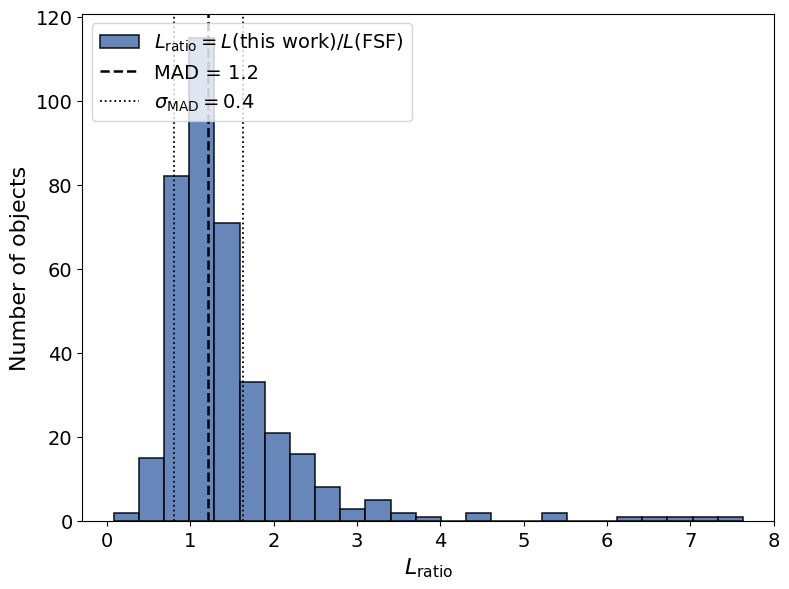

In [119]:
ratio = yy[0] / xx[0]
ratio = ratio[np.isfinite(ratio)]
fig, ax = plot_ratio_histogram(
	ratio,
	bins=25,
	figsize=(8, 6),
	color="#4C72B0",
	edgecolor="black",
	alpha=0.85,
	label=r"$L_{\mathrm{ratio}} = L(\mathrm{this\ work}) / L(\mathrm{FSF})$",
	xlabel=r"$L_{\mathrm{ratio}}$",
	add_median_value=True,
	legend_loc='upper left',
	#ylim=[0,90],
	#xlim=[-0.1,2.4]
)
